In [1]:
import pandas as pd 
from datasets import load_dataset, load_from_disk
import pyarrow.parquet as pq  
import time
import numpy as np

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pandas as pd
df = pd.read_csv("/gpfs/data/brandeslab/Data/uniref/uniref90_cluster_members.tsv", sep="\t", nrows=100)
df

,ClusterID,RepresentativeID,member_count_xml_file,member_count,MemberIDs
0,UniRef90_UPI002E2621C6,UPI002E2621C6,1,1,NaN
1,UniRef90_UPI00358F51CD,UPI00358F51CD,1,1,NaN
2,UniRef90_UPI00398E31D8,UPI00398E31D8,1,1,NaN
3,UniRef90_A0A5A9P0L4,A0A5A9P0L4_9TELE,1,1,NaN
4,UniRef90_A0ABD1JBH0,A0ABD1JBH0_9TELE,1,1,NaN
...,...,...,...,...,...
95,UniRef90_A0A6P8RG45,A0A6P8RG45_GEOSA,1,1,NaN
96,UniRef90_UPI003D69693D,UPI003D69693D,1,1,NaN
97,UniRef90_UPI003EBDD6D2,UPI003EBDD6D2,3,3,"UPI003EBC14C6,UPI003EB9A168"
98,UniRef90_A0A1V4K6M4,A0A1V4K6M4_PATFA,562,562,"A0A7K4RU14_COLPI,A0A7L4G2H3_9COLU,A0A094KAD8_A..."


In [ ]:
df.iloc[97]

ClusterID                     UniRef90_UPI003EBDD6D2
RepresentativeID                       UPI003EBDD6D2
member_count_xml_file                              3
member_count                                       3
MemberIDs                UPI003EBC14C6,UPI003EB9A168
Name: 97, dtype: object

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Split
from transformers import PreTrainedTokenizerFast

# Define vocabulary: ONLY standard 20 amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")  # Standard 20 only
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]", "-"]

# Build vocabulary
vocab = {token: i for i, token in enumerate(special_tokens + amino_acids)}

print(f"Vocab: {vocab}")
print(f"'-' ID: {vocab['-']}")

# Create tokenizer
tokenizer = Tokenizer(WordLevel(vocab=vocab, unk_token="[UNK]"))
tokenizer.pre_tokenizer = Split(pattern="", behavior="isolated")

# Wrap it
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

# Test
print("\nTests:")
print("'-' converts to:", hf_tokenizer.convert_tokens_to_ids("-"))
print("Tokenization of 'ACD-GH':", hf_tokenizer("ACD-GH"))
print("Decoding:", hf_tokenizer.decode([6, 7, 8, 5, 11, 12]))
print("Vocab size:", len(hf_tokenizer))

# hf_tokenizer.save_pretrained("phylo_char_tokenizer")

Vocab: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4, '-': 5, 'A': 6, 'C': 7, 'D': 8, 'E': 9, 'F': 10, 'G': 11, 'H': 12, 'I': 13, 'K': 14, 'L': 15, 'M': 16, 'N': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'V': 23, 'W': 24, 'Y': 25}
'-' ID: 5

Tests:
'-' converts to: 5
Tokenization of 'ACD-GH': {'input_ids': [6, 7, 8, 5, 11, 12], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
Decoding: A C D - G H
Vocab size: 26


In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Split
from transformers import PreTrainedTokenizerFast

# Define vocabulary: ONLY standard 20 amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")  # Standard 20 only
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]", "[GAP]", "-"]


# Build vocabulary
vocab = {token: i for i, token in enumerate(special_tokens + amino_acids)}

print(f"Vocab: {vocab}")
print(f"'-' ID: {vocab['-']}")
print(f"[GAP] ID: {vocab['[GAP]']}")
print(f"[MASK] ID: {vocab['[MASK]']}")

# Create tokenizer
tokenizer = Tokenizer(WordLevel(vocab=vocab, unk_token="[UNK]"))
tokenizer.pre_tokenizer = Split(pattern="", behavior="isolated")

# Wrap it
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
    additional_special_tokens=["[GAP]"]  # 👈 Register [GAP] as special
)

# Test
print("\nTests:")
print("'-' converts to:", hf_tokenizer.convert_tokens_to_ids("-"))
print("[GAP] converts to:", hf_tokenizer.convert_tokens_to_ids("[GAP]"))
print("[MASK] converts to:", hf_tokenizer.convert_tokens_to_ids("[MASK]"))
print("\n")
print("Tokenization of 'ACD-GH':", hf_tokenizer("ACD-GH", add_special_tokens=False))
print("Tokenization of  'ACD[GAP]GH':", hf_tokenizer("ACD[GAP]GH", add_special_tokens=False))
# print("Decoding:", hf_tokenizer.decode([6, 7, 8, 5, 11, 12]))
print("Vocab size:", len(hf_tokenizer))

hf_tokenizer.save_pretrained("phylo_char_tokenizer_updated")

Vocab: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4, '[GAP]': 5, '-': 6, 'A': 7, 'C': 8, 'D': 9, 'E': 10, 'F': 11, 'G': 12, 'H': 13, 'I': 14, 'K': 15, 'L': 16, 'M': 17, 'N': 18, 'P': 19, 'Q': 20, 'R': 21, 'S': 22, 'T': 23, 'V': 24, 'W': 25, 'Y': 26}
'-' ID: 6
[GAP] ID: 5
[MASK] ID: 4

Tests:
'-' converts to: 6
[GAP] converts to: 5
[MASK] converts to: 4


Tokenization of 'ACD-GH': {'input_ids': [7, 8, 9, 6, 12, 13], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
Tokenization of  'ACD[GAP]GH': {'input_ids': [7, 8, 9, 5, 12, 13], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}
Vocab size: 27


('phylo_char_tokenizer_updated/tokenizer_config.json',
 'phylo_char_tokenizer_updated/special_tokens_map.json',
 'phylo_char_tokenizer_updated/tokenizer.json')

In [ ]:
import sys
print(sys.executable)

/gpfs/home/as12267/.conda/envs/huggingface_bert/bin/python


In [ ]:
import sys
[p for p in sys.path if "conda" in p]

['/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python310.zip',
 '/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10',
 '/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/lib-dynload',
 '/gpfs/home/as12267/.conda/envs/huggingface_bert/lib/python3.10/site-packages']

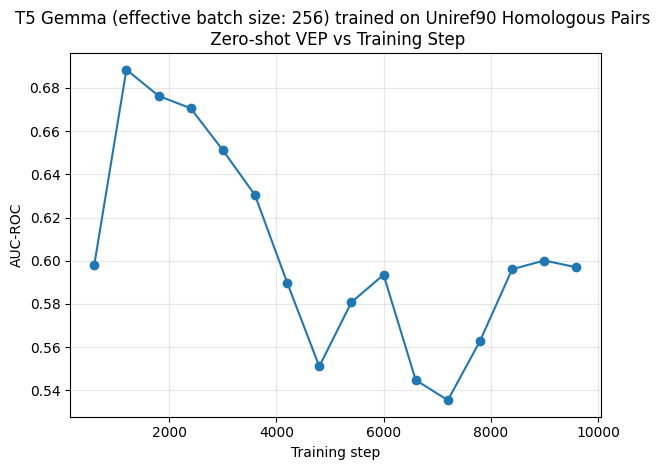

In [1]:
import matplotlib.pyplot as plt

auc_roc = {
    "600":0.5980351745736494, 
    "1200":0.688444796092619, 
    "1800":0.6763199707125005,
    "2400":0.6705564691049782,
    "3000":0.6511683988289553,
    "3600":0.6303775921434881,
    "4200":0.5898707215564856,
    "4800":0.551087956647428, 
    "5400":0.5807938823325738,
    "6000":0.5935137716130717, 
    "6600":0.5447643061826358,
    "7200":0.5354546610367745,
    "7800":0.56284729430975,
    "8400":0.5960752394700923, 
    "9000":0.6001126155029131, 
    "9600":0.5969622057476387
}

# sort by step (convert keys to int so sorting is numeric)
steps = sorted(int(k) for k in auc_roc.keys())
aucs  = [auc_roc[str(s)] for s in steps]

plt.figure()
plt.plot(steps, aucs, marker="o")
plt.xlabel("Training step")
plt.ylabel("AUC-ROC")
plt.title("T5 Gemma (effective batch size: 256) trained on Uniref90 Homologous Pairs \n Zero-shot VEP vs Training Step")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
TSV = "/gpfs/data/brandeslab/Data/uniref/uniref90_cluster_members_ge2_bk_test.tsv"

hist = {}
n = 0
total = 0
mn = 10**18
mx = 0

def bin_label(m: int) -> str:
    if m == 2:
        return "2"
    lo = 2 ** (m.bit_length() - 1)
    hi = 2 ** (m.bit_length()) - 1
    lo = max(lo, 3)
    return f"{lo}-{hi}"

with open(TSV, "r") as f:
    header = next(f)  # skip header
    for line in f:
        # split only first 2 tabs: cluster_id, member_count, (rest ignored)
        parts = line.rstrip("\n").split("\t", 2)
        if len(parts) < 2:
            continue
        m = int(parts[1])
        if m < 2:
            continue

        n += 1
        total += m
        mn = min(mn, m)
        mx = max(mx, m)

        b = bin_label(m)
        hist[b] = hist.get(b, 0) + 1

print(f"clusters (m>=2): {n:,}")
print(f"min: {mn}, max: {mx}, mean: {total/n:.3f}")

clusters (m>=2): 53,506,765
min: 2, max: 26930, mean: 6.188


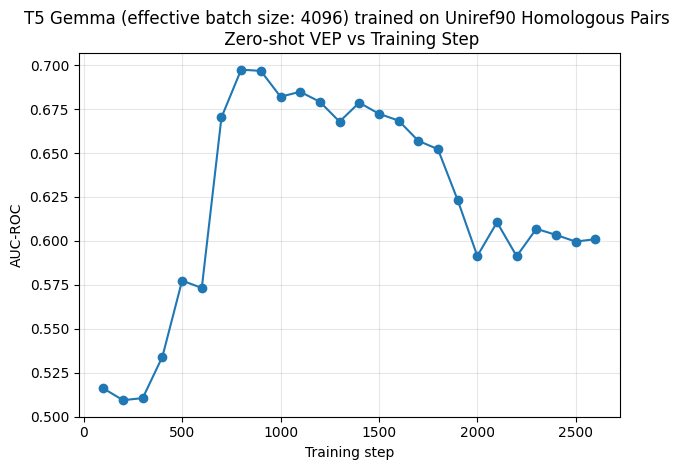

In [1]:
import matplotlib.pyplot as plt

auc_roc = {
    "100":0.5160, 
    "200":0.5093, 
    "300":0.5105,
    "400":0.5341,
    "500":0.5774,
    "600":0.5732,
    "700":0.6703,
    "800":0.6975, 
    "900":0.6968,
    "1000":0.6821, 
    "1100":0.6849,
    "1200":0.6792,
    "1300":0.6679,
    "1400":0.6787, 
    "1500":0.6724, 
    "1600":0.6685, 
    "1700":0.6570, 
    "1800":0.6522, 
    "1900":0.6233, 
    "2000":0.5914, 
    "2100":0.6106, 
    "2200":0.5913, 
    "2300":0.6069, 
    "2400":0.6034, 
    "2500":0.5996, 
    "2600":0.6010
}

# sort by step (convert keys to int so sorting is numeric)
steps = sorted(int(k) for k in auc_roc.keys())
aucs  = [auc_roc[str(s)] for s in steps]

plt.figure()
plt.plot(steps, aucs, marker="o")
plt.xlabel("Training step")
plt.ylabel("AUC-ROC")
plt.title("T5 Gemma (effective batch size: 4096) trained on Uniref90 Homologous Pairs \n Zero-shot VEP vs Training Step")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

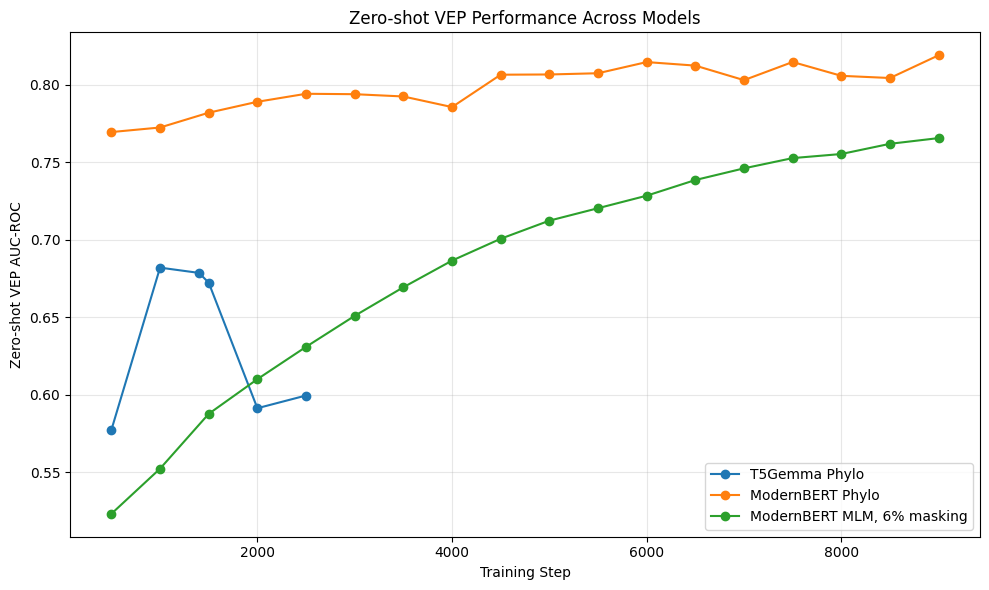

In [3]:
t5_gemma_auc_roc = {
    "500":0.5774,
    "1000":0.6821, 
    "1400":0.6787, 
    "1500": 0.6724, 
    "2000": 0.5914, 
    "2500":0.5996
}


modernBERT_phylo_auc_roc = {
    "500":0.76957,
    "1000":0.77251,
    "1500":0.78206,
    "2000":0.78911, 
    "2500":0.79427,
    "3000":0.794,
    "3500":0.79253,
    "4000":0.78569, 
    "4500":0.80658,
    "5000":0.80672,
    "5500":0.80752,
    "6000":0.81472,
    "6500":0.81244,
    "7000":0.80307,
    "7500":0.81477, 
    "8000":0.80585, 
    "8500":0.80444, 
    "9000":0.81912
}   

modernBERT_mlm_6_auc_roc = {
    "500":0.52328,
    "1000":0.5524,
    "1500":0.58777,
    "2000":0.61014, 
    "2500":0.63099,
    "3000":0.651,
    "3500":0.66944,
    "4000":0.68664, 
    "4500":0.70073,
    "5000":0.71241,
    "5500":0.72044,
    "6000":0.72852,
    "6500":0.73862,
    "7000":0.74616,
    "7500":0.75277, 
    "8000":0.75541, 
    "8500":0.76199, 
    "9000":0.76568
}  


def sort_xy(d):
    x = sorted(int(k) for k in d.keys())
    y = [d[str(step)] for step in x]
    return x, y

x1, y1 = sort_xy(t5_gemma_auc_roc)
x2, y2 = sort_xy(modernBERT_phylo_auc_roc)
x3, y3 = sort_xy(modernBERT_mlm_6_auc_roc)

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, marker='o', label='T5Gemma Phylo')
plt.plot(x2, y2, marker='o', label='ModernBERT Phylo')
plt.plot(x3, y3, marker='o', label='ModernBERT MLM, 6% masking')

plt.xlabel("Training Step")
plt.ylabel("Zero-shot VEP AUC-ROC")
plt.title("Zero-shot VEP Performance Across Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




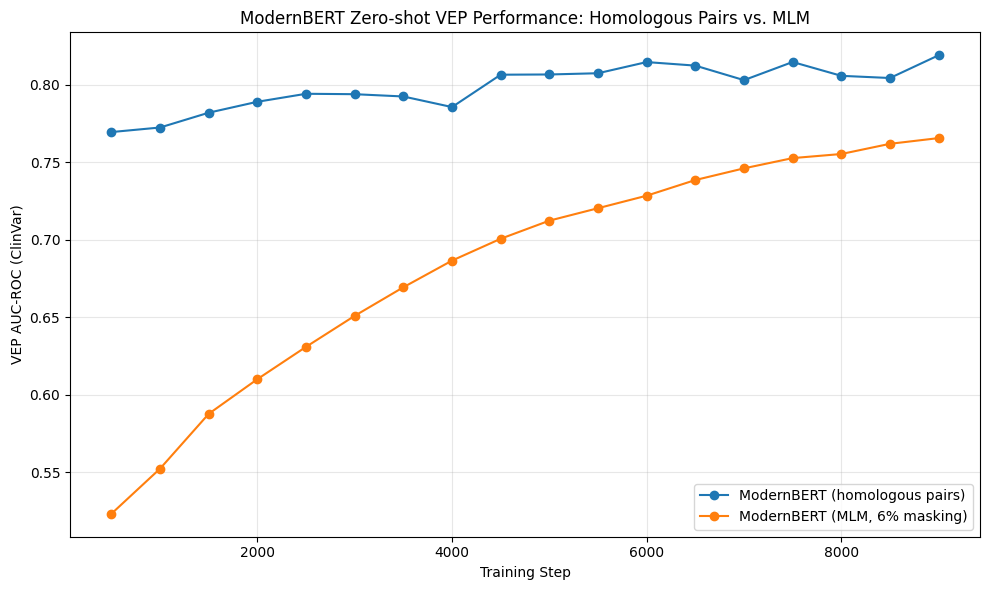

In [ ]:
import matplotlib.pyplot as plt

modernBERT_phylo_auc_roc = {
    "500":0.76957,
    "1000":0.77251,
    "1500":0.78206,
    "2000":0.78911, 
    "2500":0.79427,
    "3000":0.794,
    "3500":0.79253,
    "4000":0.78569, 
    "4500":0.80658,
    "5000":0.80672,
    "5500":0.80752,
    "6000":0.81472,
    "6500":0.81244,
    "7000":0.80307,
    "7500":0.81477, 
    "8000":0.80585, 
    "8500":0.80444, 
    "9000":0.81912
}   

modernBERT_mlm_6_auc_roc = {
    "500":0.52328,
    "1000":0.5524,
    "1500":0.58777,
    "2000":0.61014, 
    "2500":0.63099,
    "3000":0.651,
    "3500":0.66944,
    "4000":0.68664, 
    "4500":0.70073,
    "5000":0.71241,
    "5500":0.72044,
    "6000":0.72852,
    "6500":0.73862,
    "7000":0.74616,
    "7500":0.75277, 
    "8000":0.75541, 
    "8500":0.76199, 
    "9000":0.76568
}  


def sort_xy(d):
    x = sorted(int(k) for k in d.keys())
    y = [d[str(step)] for step in x]
    return x, y

x1, y1 = sort_xy(modernBERT_phylo_auc_roc)
x2, y2 = sort_xy(modernBERT_mlm_6_auc_roc)

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, marker='o', label='ModernBERT (homologous pairs)')
plt.plot(x2, y2, marker='o', label='ModernBERT (MLM, 6% masking)')

plt.xlabel("Training Step")
plt.ylabel("VEP AUC-ROC (ClinVar)")
plt.title("ModernBERT Zero-shot VEP Performance: Homologous Pairs vs. MLM")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Saved plot to vep_auc_comparison.png


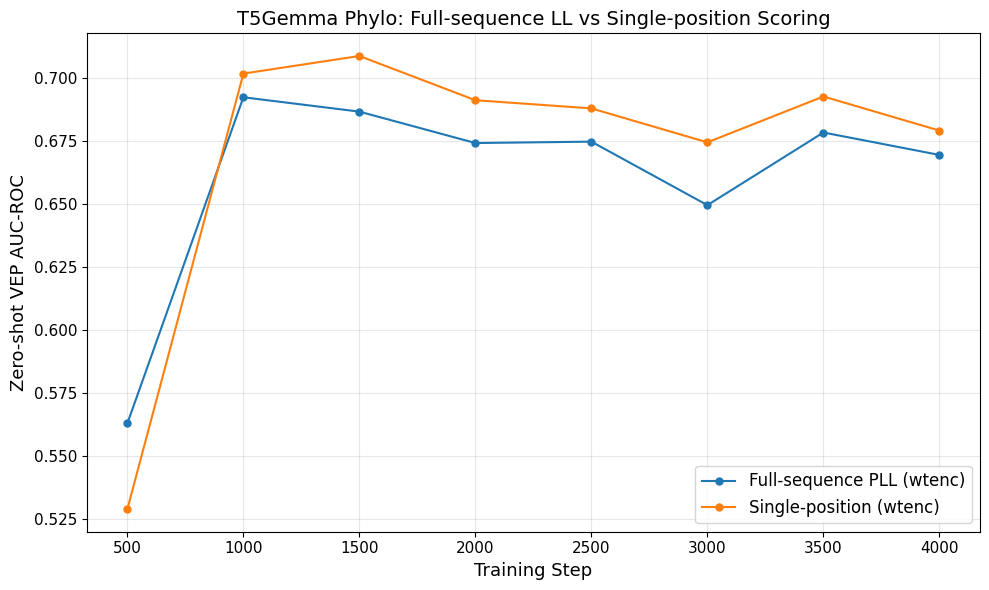

In [3]:
#!/usr/bin/env python3
"""
Plot zero-shot VEP AUC-ROC for two scoring modes on the same axes.

Usage:
    python plot_vep_comparison.py
"""

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
wtenc_dir = "/gpfs/data/brandeslab/User/as12267/T5Gemma_97M_phylo_bs_4096_arrow_fasta_file_zero_shot_vep_full_seq_LL_wtenc"
singlepos_dir = "/gpfs/data/brandeslab/User/as12267/T5Gemma_97M_phylo_bs_4096_arrow_fasta_file_zero_shot_vep_singlepos_wtenc"
out_path = "vep_auc_comparison.png"


def load_results(directory: str, auc_col: str) -> pd.DataFrame:
    """Read all CSVs in a directory, extract step from checkpoint_dir and the relevant AUC column."""
    csvs = sorted(glob.glob(os.path.join(directory, "*.csv")))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {directory}")

    rows = []
    for f in csvs:
        df = pd.read_csv(f)
        for _, row in df.iterrows():
            # Extract step from checkpoint_dir, e.g. "checkpoint-1000" -> 1000
            ckpt_dir = str(row["checkpoint_dir"])
            step = int(ckpt_dir.split("-")[-1])
            auc = row.get(auc_col)
            if pd.isna(auc) or auc == "":
                continue
            rows.append({"step": step, "auc": float(auc)})

    result = pd.DataFrame(rows).sort_values("step")
    return result


# --- Load data ---
df_wtenc = load_results(wtenc_dir, auc_col="auc_pll_wtenc")
df_singlepos = load_results(singlepos_dir, auc_col="auc_pll_singlepos")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_wtenc["step"], df_wtenc["auc"], marker="o", markersize=5,
        label="Full-sequence PLL (wtenc)", color="tab:blue")
ax.plot(df_singlepos["step"], df_singlepos["auc"], marker="o", markersize=5,
        label="Single-position (wtenc)", color="tab:orange")

ax.set_xlabel("Training Step", fontsize=13)
ax.set_ylabel("Zero-shot VEP AUC-ROC", fontsize=13)
ax.set_title("T5Gemma Phylo: Full-sequence LL vs Single-position Scoring", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(out_path, dpi=150)
print(f"Saved plot to {out_path}")
plt.show()

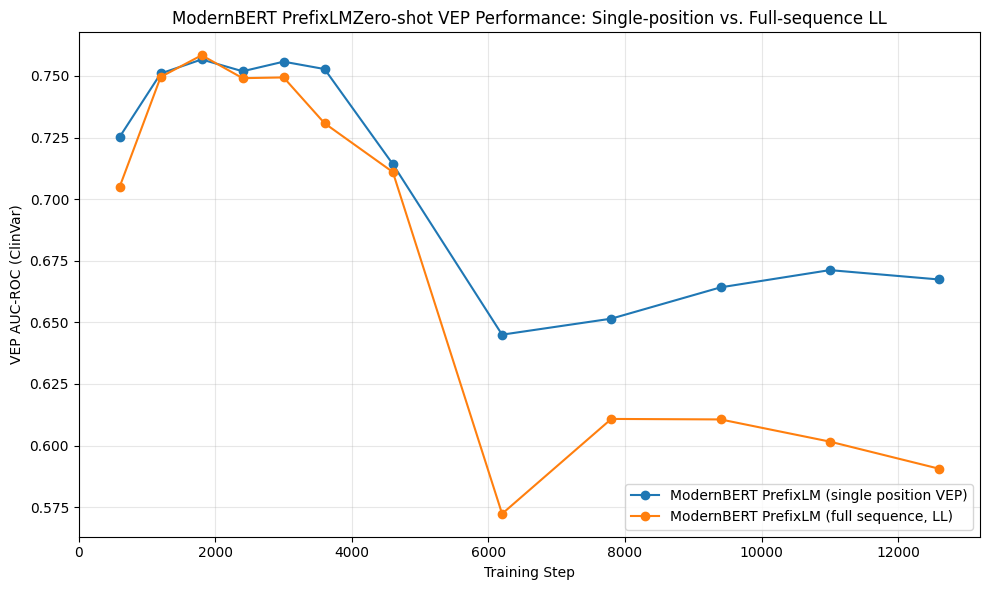

In [ ]:
import matplotlib.pyplot as plt

modernBERT_prefixlm_single_pos = {
    "600":0.7253,
    "1200":0.7510,
    "1800":0.7567,
    "2400":0.7519,
    "3000":0.7558, 
    "3600":0.7528, 
    "4600":0.7142, 
    "6200":0.6450,
    "7800":0.6515,
    "9400":0.6642,
    "11000":0.6712, 
    "12600":0.6674,

}   



modernBERT_prefixlm_full_seq_LL = {
    "600":0.7051,
    "1200":0.7496,
    "1800":0.7584,
    "2400":0.7491,
    "3000":0.7494, 
    "3600":0.7308,
    "4600":0.7110,
    "6200":0.5723, 
    "7800":0.6108, 
    "9400":0.6106,
    "11000":0.6016, 
    "12600":0.5906

}  



def sort_xy(d):
    x = sorted(int(k) for k in d.keys())
    y = [d[str(step)] for step in x]
    return x, y

x1, y1 = sort_xy(modernBERT_prefixlm_single_pos)
x2, y2 = sort_xy(modernBERT_prefixlm_full_seq_LL)

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, marker='o', label='ModernBERT PrefixLM (single position VEP)')
plt.plot(x2, y2, marker='o', label='ModernBERT PrefixLM (full sequence, LL)')

plt.xlabel("Training Step")
plt.ylabel("VEP AUC-ROC (ClinVar)")
plt.title("ModernBERT PrefixLM Zero-shot VEP Performance: Single-position vs. Full-sequence LL")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
from gLM.dataset.uniref90_pair_arrow_fasta import Uniref90ArrowDatasetForFASTA


train_file = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/train"
fasta_file = "/gpfs/data/brandeslab/Data/uniref/uniref100.fasta"
idx_file = "/gpfs/data/brandeslab/User/as12267/uniref100.idx"
train_ds = Uniref90ArrowDatasetForFASTA(dataset_path=train_file,
                                  training_type="phylo_encoder_decoder", 
                                  fasta_path=fasta_file, 
                                  idx_db_path=idx_file)
print(train_ds)


In [3]:
# 1. Check the length
print(f"Dataset length: {len(train_ds)}")

# 2. Get a single example
example = train_ds[0]
print(f"\nFirst example type: {type(example)}")
print(f"First example: {example}")

# 3. Check multiple examples
print("\n--- First 3 examples ---")
for i in range(3):
    ex = train_ds[i]
    if isinstance(ex, tuple):
        s1, s2 = ex
        print(f"Example {i}: len(s1)={len(s1)}, len(s2)={len(s2)}")
        print(f"  s1[:50]: {s1[:50]}")
        print(f"  s2[:50]: {s2[:50]}")
    else:
        print(f"Example {i}: {ex[:50]}...")

# 4. Check the underlying HF dataset
print(f"\nUnderlying dataset info:")
print(f"  Type: {type(train_ds.dataset)}")
print(f"  Num rows: {train_ds.dataset.num_rows}")
print(f"  Column names: {train_ds.dataset.column_names}")
print(f"  Features: {train_ds.dataset.features}")

Dataset length: 53405637

First example type: <class 'tuple'>
First example: ('MSSNITECELEHRLLAEVASRRQAFLQALQALDLELALQFQQLPADEWADHGALSAWPQLQPHITQLKQLDAALCQQLLGLYGLCSDCEAELSYELLYQDPCRQRCAQCELKHLNSQHTSWTL', 'MSSNITECELEHRLLAEVASRRQAFLQALQALDLELALQFQQLPADEWADHGALSAWPQLQPHITQLKQLDAALCQQLLGLYGLCSDCEAELSYEQLYQDPCRQRCARCEAKYQNSQQGSWQL')

--- First 3 examples ---
Example 0: len(s1)=341, len(s2)=341
  s1[:50]: MCHFCTTHADGGKWFENAANFSAKMYSNRKKKVAKEEKFTQHMGGVPVKI
  s2[:50]: MCHFCTTHADGGKWFENASNFAARMYSNRKKKVEKQDKFTQHMGGVPIKI
Example 1: len(s1)=145, len(s2)=145
  s1[:50]: MSNDLRNYAATLAIVTSFWTHPVIADEPGSAYYAALNKAIVAGKELRMLV
  s2[:50]: MSNDLRNYAATLAIVTSFWTHPVIADEPGSADYAALNKAIIDGKELRMLV
Example 2: len(s1)=81, len(s2)=81
  s1[:50]: MASISPSSSNSTSTPSVAEQRMQLKLHEVALAELNNHPSSRAVYRKNGKL
  s2[:50]: MASISPSSSNSTSTPSVANQTRQMKLHEVALAELNNHPSSRAVYRKNGNL

Underlying dataset info:
  Type: <class 'datasets.arrow_dataset.Dataset'>
  Num rows: 53405637
  Column names: ['cluster_id', 'member_ids']
  Features: {'cluster_i

In [1]:
from datasets import load_from_disk
from tqdm import tqdm

train_path = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/train"
test_path  = "/gpfs/data/brandeslab/Data/uniref/uniref90_clusters_arrow/test"

train_ds = load_from_disk(train_path)
test_ds  = load_from_disk(test_path)

# test is small enough to keep in memory
test_ids = set(test_ds["cluster_id"])

print(f"n test rows: {len(test_ds):,}")
print(f"n unique test cluster_ids: {len(test_ids):,}")

overlaps = []

for row in tqdm(train_ds, total=len(train_ds), desc="Checking train"):
    cid = row["cluster_id"]
    if cid in test_ids:
        overlaps.append(cid)
        if len(overlaps) >= 20:
            break

if overlaps:
    print(f"FOUND overlap! Showing first {len(overlaps)}:")
    print(overlaps)
else:
    print("No overlap found between train and test cluster_id values.")

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n test rows: 101,128
n unique test cluster_ids: 101,128


Checking train: 100%|██████████| 53405637/53405637 [22:04<00:00, 40317.97it/s]

No overlap found between train and test cluster_id values.


In [3]:
unierf90_members = pd.read_csv("/gpfs/data/brandeslab/Data/uniref/uniref90_cluster_members.tsv", sep="\t", nrows=100)
unierf90_members

,ClusterID,RepresentativeID,member_count_xml_file,member_count,MemberIDs
0,UniRef90_UPI002E2621C6,UPI002E2621C6,1,1,NaN
1,UniRef90_UPI00358F51CD,UPI00358F51CD,1,1,NaN
2,UniRef90_UPI00398E31D8,UPI00398E31D8,1,1,NaN
3,UniRef90_A0A5A9P0L4,A0A5A9P0L4_9TELE,1,1,NaN
4,UniRef90_A0ABD1JBH0,A0ABD1JBH0_9TELE,1,1,NaN
...,...,...,...,...,...
95,UniRef90_A0A6P8RG45,A0A6P8RG45_GEOSA,1,1,NaN
96,UniRef90_UPI003D69693D,UPI003D69693D,1,1,NaN
97,UniRef90_UPI003EBDD6D2,UPI003EBDD6D2,3,3,"UPI003EBC14C6,UPI003EB9A168"
98,UniRef90_A0A1V4K6M4,A0A1V4K6M4_PATFA,562,562,"A0A7K4RU14_COLPI,A0A7L4G2H3_9COLU,A0A094KAD8_A..."


In [2]:
uniref50_members = pd.read_csv("/gpfs/data/brandeslab/Data/uniref/uniref50_cluster_members.tsv", sep="\t", nrows=100)
uniref50_members

,ClusterID,RepresentativeID,member_count_xml_file,member_count,MemberIDs
0,UniRef50_UPI002E2621C6,NaN,1,1,NaN
1,UniRef50_UPI00358F51CD,NaN,1,1,NaN
2,UniRef50_UPI00398E31D8,NaN,1,1,NaN
3,UniRef50_A0A5A9P0L4,NaN,1,1,NaN
4,UniRef50_A0ABD1JBH0,NaN,1,1,NaN
...,...,...,...,...,...
95,UniRef50_A0A812BEH1,NaN,1,1,NaN
96,UniRef50_A0A9D3NX19,NaN,249,1,NaN
97,UniRef50_UPI0038B66B51,NaN,1,1,NaN
98,UniRef50_A0ABD3APF5,NaN,1,1,NaN


In [1]:
import xml.etree.ElementTree as ET
path = "/gpfs/data/brandeslab/Data/uniref/uniref50.xml"
context = ET.iterparse(open(path, "rb"), events=("end",))
for event, elem in context:
    if elem.tag == "{http://uniprot.org/uniref}entry":
        ET.indent(elem)
        print(ET.tostring(elem, encoding="unicode"))
        break

<ns0:entry xmlns:ns0="http://uniprot.org/uniref" id="UniRef50_UPI002E2621C6" updated="2024-05-29">
  <ns0:name>Cluster: uncharacterized protein LOC134193701</ns0:name>
  <ns0:property type="member count" value="1" />
  <ns0:property type="common taxon" value="Corticium candelabrum" />
  <ns0:property type="common taxon ID" value="121492" />
  <ns0:representativeMember>
    <ns0:dbReference type="UniParc ID" id="UPI002E2621C6">
      <ns0:property type="UniRef100 ID" value="UniRef100_UPI002E2621C6" />
      <ns0:property type="UniRef90 ID" value="UniRef90_UPI002E2621C6" />
      <ns0:property type="protein name" value="uncharacterized protein LOC134193701" />
      <ns0:property type="source organism" value="Corticium candelabrum" />
      <ns0:property type="NCBI taxonomy" value="121492" />
      <ns0:property type="length" value="49499" />
      <ns0:property type="isSeed" value="true" />
    </ns0:dbReference>
    <ns0:sequence length="49499" checksum="428270C7C0D6A56C">...</ns0:sequ

In [2]:
import xml.etree.ElementTree as ET
path = "/gpfs/data/brandeslab/Data/uniref/uniref90.xml"
context = ET.iterparse(open(path, "rb"), events=("end",))
for event, elem in context:
    if elem.tag == "{http://uniprot.org/uniref}entry":
        ET.indent(elem)
        print(ET.tostring(elem, encoding="unicode"))
        break

<ns0:entry xmlns:ns0="http://uniprot.org/uniref" id="UniRef90_UPI002E2621C6" updated="2024-05-29">
  <ns0:name>Cluster: uncharacterized protein LOC134193701</ns0:name>
  <ns0:property type="member count" value="1" />
  <ns0:property type="common taxon" value="Corticium candelabrum" />
  <ns0:property type="common taxon ID" value="121492" />
  <ns0:representativeMember>
    <ns0:dbReference type="UniParc ID" id="UPI002E2621C6">
      <ns0:property type="UniRef100 ID" value="UniRef100_UPI002E2621C6" />
      <ns0:property type="UniRef50 ID" value="UniRef50_UPI002E2621C6" />
      <ns0:property type="protein name" value="uncharacterized protein LOC134193701" />
      <ns0:property type="source organism" value="Corticium candelabrum" />
      <ns0:property type="NCBI taxonomy" value="121492" />
      <ns0:property type="length" value="49499" />
      <ns0:property type="isSeed" value="true" />
    </ns0:dbReference>
    <ns0:sequence length="49499" checksum="428270C7C0D6A56C">...</ns0:sequ

In [3]:
import xml.etree.ElementTree as ET
path = "/gpfs/data/brandeslab/Data/uniref/uniref90.xml"
context = ET.iterparse(open(path, "rb"), events=("end",))
for event, elem in context:
    if elem.tag == "{http://uniprot.org/uniref}entry":
        rep = elem.find(".//{http://uniprot.org/uniref}representativeMember/{http://uniprot.org/uniref}dbReference[@type='UniRef100']")
        print("rep with filter:", rep)
        rep2 = elem.find(".//{http://uniprot.org/uniref}representativeMember/{http://uniprot.org/uniref}dbReference")
        print("rep no filter:", rep2.attrib if rep2 is not None else None)
        break

rep with filter: None
rep no filter: {'type': 'UniParc ID', 'id': 'UPI002E2621C6'}


In [6]:
import gzip
import sys
import xml.etree.ElementTree as ET
from tqdm import tqdm

# Path to UniRef50 XML (can be .xml.gz)
INPUT_XML = "/gpfs/data/brandeslab/Data/uniref/uniref50.xml"
OUTPUT_TSV = "/gpfs/data/brandeslab/Data/uniref/uniref50_cluster_members.tsv"
TOTAL_CLUSTERS = 58_875_981

# Namespaces
NS = "{http://uniprot.org/uniref}"
TARGET_PROP = "UniRef90 ID"  # UniRef50 clusters are composed of UniRef90 representatives


def stream_uniref50(xml_path, out_path):
    # Open XML or .gz
    if xml_path.endswith(".gz"):
        f = gzip.open(xml_path, "rb")
    else:
        f = open(xml_path, "rb")

    total_processed = 0
    total_skipped = 0

    with open(out_path, "w") as out:
        out.write("ClusterID\tRepresentativeID\tmember_count_xml_file\tmember_count\tMemberIDs\n")

        context = ET.iterparse(f, events=("end",))
        pbar = tqdm(desc="Parsing clusters", unit="cluster", total=TOTAL_CLUSTERS,
                    ncols=100, file=sys.stdout, dynamic_ncols=True)

        for event, elem in context:
            if elem.tag == f"{NS}entry":
                try:
                    cluster_id = elem.attrib.get("id", "NA")

                    # === Representative Member ===
                    # Pull UniRef90 ID from the <property> child of <dbReference>
                    rep_id = "NA"
                    rep_db = elem.find(f"./{NS}representativeMember/{NS}dbReference")
                    if rep_db is not None:
                        rep_prop = rep_db.find(f"./{NS}property[@type='{TARGET_PROP}']")
                        if rep_prop is not None:
                            rep_id = rep_prop.attrib.get("value", "NA")

                    # === Non-representative Members ===
                    members = []
                    for m_db in elem.findall(f"./{NS}member/{NS}dbReference"):
                        m_prop = m_db.find(f"./{NS}property[@type='{TARGET_PROP}']")
                        if m_prop is not None:
                            members.append(m_prop.attrib.get("value", "NA"))

                    # Total member count includes the representative
                    member_count_with_rep = len(members) + (1 if rep_id != "NA" else 0)

                    # === XML-reported member count ===
                    xml_prop = elem.find(f"./{NS}property[@type='member count']")
                    member_count_xml = xml_prop.attrib.get("value", "NA") if xml_prop is not None else "NA"

                    member_str = ",".join(members)

                    out.write(f"{cluster_id}\t{rep_id}\t{member_count_xml}\t{member_count_with_rep}\t{member_str}\n")
                    total_processed += 1

                except Exception as e:
                    tqdm.write(f"[WARN] Skipping malformed cluster {elem.attrib.get('id', 'NA')}: {e}")
                    total_skipped += 1

                finally:
                    elem.clear()
                    pbar.update(1)

        pbar.close()
        f.close()

    tqdm.write(f"\n Finished writing to {out_path}")
    tqdm.write(f" Total clusters processed: {total_processed}")
    tqdm.write(f"Total clusters skipped  : {total_skipped}")


def extract_entry_by_id(xml_path, cluster_id, output_path):
    """Extract a single <entry> block by UniRef cluster ID"""
    open_func = gzip.open if xml_path.endswith(".gz") else open

    with open_func(xml_path, "rb") as f_in, open(output_path, "wb") as f_out:
        f_out.write(b"<?xml version='1.0' encoding='UTF-8'?>\n<UniRef50>\n")

        context = ET.iterparse(f_in, events=("end",))
        for event, elem in context:
            if elem.tag == f"{NS}entry":
                if elem.attrib.get("id") == cluster_id:
                    ET.ElementTree(elem).write(f_out, encoding="utf-8")
                    break
                elem.clear()

        f_out.write(b"</UniRef50>\n")

    print(f" Extracted cluster {cluster_id} to {output_path}")


def extract_first_n_entries(xml_path, n, output_path):
    """Extract the first N <entry> blocks to a small XML file for testing."""
    open_func = gzip.open if xml_path.endswith(".gz") else open

    count = 0
    with open_func(xml_path, "rb") as f_in, open(output_path, "wb") as f_out:
        f_out.write(b"<?xml version='1.0' encoding='UTF-8'?>\n<UniRef50>\n")
        context = ET.iterparse(f_in, events=("end",))
        for event, elem in context:
            if elem.tag == f"{NS}entry":
                ET.ElementTree(elem).write(f_out, encoding="utf-8")
                count += 1
                elem.clear()
                if count >= n:
                    break
        f_out.write(b"</UniRef50>\n")

    print(f"Extracted {count} entries to {output_path}")

extract_first_n_entries(INPUT_XML, 100, "test_uniref50.xml")
stream_uniref50("test_uniref50.xml", "test_uniref50.tsv")

# if __name__ == "__main__":
#     stream_uniref50(INPUT_XML, OUTPUT_TSV)

Extracted 100 entries to test_uniref50.xml
Parsing clusters:   0%|          | 100/58875981 [00:00<28:25:14, 575.44cluster/s]
                                                                                   
 Finished writing to test_uniref50.tsv
 Total clusters processed: 100                                                     
Total clusters skipped  : 0                                                        
Parsing clusters:   0%|          | 18993/58875981 [01:27<4:26:00, 3687.67cluster/s]

In [1]:
from Bio import SeqIO
idx = SeqIO.index_db(
    "/gpfs/data/brandeslab/User/as12267/uniref100.idx",
    ["/gpfs/data/brandeslab/Data/uniref/uniref100.fasta"],
    "fasta",
)
rec = idx["UniRef100_UPI0034443B5C"]
print(rec.id, len(rec.seq))

UniRef100_UPI0034443B5C 732


In [4]:
from Bio import SeqIO

idx = SeqIO.index_db(
    "/gpfs/data/brandeslab/User/as12267/uniref90.idx",
    ["/gpfs/data/brandeslab/Data/uniref/uniref90.fasta"],
    "fasta",
)

print("Number of records:", len(idx))

for i, key in enumerate(idx.keys()):
    print(key)
    if i == 20:
        break

Number of records: 184146434
UniRef90_UPI002E2621C6
UniRef90_UPI00358F51CD
UniRef90_UPI00398E31D8
UniRef90_A0A5A9P0L4
UniRef90_A0ABD1JBH0
UniRef90_A0AB34IYJ6
UniRef90_A0ABC9HIT3
UniRef90_UPI0033D09B30
UniRef90_UPI00342936FC
UniRef90_UPI0037AAB210
UniRef90_A0ABC9HG52
UniRef90_UPI00312B5ECC
UniRef90_UPI0033D4639E
UniRef90_A0ABP9R8T0
UniRef90_UPI002E22A622
UniRef90_A0A410P257
UniRef90_A0A8J3NBY6
UniRef90_A0ABC9HH13
UniRef90_UPI00352B237A
UniRef90_A0A2G8LL50
UniRef90_UPI00352BB3A6


In [7]:
from datasets import load_from_disk

ds_path = "/gpfs/data/brandeslab/Data/uniref/uniref50_clusters_arrow/train"
ds = load_from_disk(ds_path)

print(ds)
print(ds[0].keys())

for i in range(5):
    ex = ds[i]
    print("cluster_id:", ex["cluster_id"])
    print("first member_ids:", ex["member_ids"][:10])
    print()

Dataset({
    features: ['cluster_id', 'member_ids'],
    num_rows: 12215523
})
dict_keys(['cluster_id', 'member_ids'])
cluster_id: UniRef50_A0ABC9HH13
first member_ids: ['UniRef90_A0ABC9HH13', 'UniRef90_A0ABC9HIT3', 'UniRef90_A0ABC9HG52']

cluster_id: UniRef50_Q8WZ42
first member_ids: ['UniRef90_A2ASS6', 'UniRef90_Q8WZ42', 'UniRef90_A0A8C4YJK0', 'UniRef90_A0A8W4FJI8', 'UniRef90_A0ABM3TZN4', 'UniRef90_A0A851J775', 'UniRef90_A0A8B8T0Q9', 'UniRef90_A0A667HB73', 'UniRef90_A0A8D2H351', 'UniRef90_A0A091JPI2']

cluster_id: UniRef50_A0A2G8LL50
first member_ids: ['UniRef90_A0A2G8LL50', 'UniRef90_UPI003AB87DBF', 'UniRef90_UPI003AB68C22', 'UniRef90_UPI003AB6D298', 'UniRef90_UPI003AB6E641', 'UniRef90_UPI003AB7A90E', 'UniRef90_UPI003AB3C7BB', 'UniRef90_UPI003AB12A49', 'UniRef90_UPI003AB3DE77', 'UniRef90_UPI003AB80605']

cluster_id: UniRef50_A0A401TRQ8
first member_ids: ['UniRef90_A0A401TRQ8', 'UniRef90_UPI000CCBE8A9', 'UniRef90_UPI00355A90FA']

cluster_id: UniRef50_A0A9Y4N860
first member_ids: ['U

In [8]:
from gLM.dataset.uniref90_pair_arrow_fasta import Uniref90ArrowDatasetForFASTA
from gLM.sequences import SequenceFetcher 

train_file = "/gpfs/data/brandeslab/Data/uniref/uniref50_clusters_arrow/train"
fasta_file = "/gpfs/data/brandeslab/Data/uniref/uniref90.fasta"
index_file = "/gpfs/data/brandeslab/User/as12267/uniref90.idx"


VALID_AA = set("ACDEFGHIKLMNPQRSTVWYBXZJUO")  # standard + ambiguous
VALID_AA_ALIGNED = VALID_AA | {"-"}


def check_seq(s, allow_gaps=False):
    assert isinstance(s, str), f"expected str, got {type(s)}"
    assert len(s) > 0, "empty sequence"
    chars = set(s.upper())
    allowed = VALID_AA_ALIGNED if allow_gaps else VALID_AA
    bad = chars - allowed
    assert not bad, f"unexpected chars: {bad}"


# -- MLM: returns a single sequence --
print("Testing MLM...")
ds = Uniref90ArrowDatasetForFASTA(train_file, "MLM", fasta_file, index_file)
print(f"  dataset size: {len(ds):,}")
for i in range(5):
    s = ds[i]
    check_seq(s)
    print(f"  [{i}] len={len(s)}  {s[:40]}...")

# -- phylo_encoder_decoder: returns (s1, s2) --
print("\nTesting phylo_encoder_decoder...")
ds = Uniref90ArrowDatasetForFASTA(train_file, "phylo_encoder_decoder", fasta_file, index_file)
for i in range(5):
    s1, s2 = ds[i]
    check_seq(s1)
    check_seq(s2)
    assert s1 != s2, "got identical sequences in a pair"
    print(f"  [{i}] len1={len(s1)} len2={len(s2)}")

# -- phylo_encoder_only: returns (a1, a2, pid) --
print("\nTesting phylo_encoder_only...")
ds = Uniref90ArrowDatasetForFASTA(train_file, "phylo_encoder_only", fasta_file, index_file)
for i in range(5):
    a1, a2, pid = ds[i]
    check_seq(a1, allow_gaps=True)
    check_seq(a2, allow_gaps=True)
    assert len(a1) == len(a2), f"alignment length mismatch: {len(a1)} vs {len(a2)}"
    assert 0.0 <= pid <= 100.0, f"pid out of range: {pid}"
    print(f"  [{i}] aln_len={len(a1)} pid={pid:.1f}%")

print("\nAll tests passed.")

Testing MLM...
  dataset size: 12,215,523
  [0] len=374  MIDNYLRQLSDTLKRHGVDKPVAVVDLDRLDANCAAATKG...
  [1] len=116  MKGITFPAWHGKHYVTLAELIVRLGSFGLDLTWRVELDEI...
  [2] len=394  MLALLGLLVAVRSEPSVPECFTVNGRDYRGSVNHAGAEKI...
  [3] len=446  MATVCWPYFDPEYENFSNRINPPRVSVDNATCHNCTLIKV...
  [4] len=87  LIGYLYPDLGKALKPLGDGFIALIKMMIAPVIFCTVVHGI...

Testing phylo_encoder_decoder...
  [0] len1=419 len2=362
  [1] len1=389 len2=351
  [2] len1=638 len2=635
  [3] len1=338 len2=335
  [4] len1=630 len2=630

Testing phylo_encoder_only...
  [0] aln_len=99 pid=66.7%
  [1] aln_len=691 pid=51.7%
  [2] aln_len=152 pid=83.6%
  [3] aln_len=182 pid=50.0%
  [4] aln_len=556 pid=89.4%

All tests passed.
